# Spike sorting
&#x26a0;&#xfe0f; **Note** &#x26a0;&#xfe0f;

This notebook demonstrates a spike sorting workflow with kilosort4.

- Spike sorting is computationally intensive and typically benefits from a GPU. Currently, spikeinterface supports NVIDIA GPUs.
- For GPU, please install the cuda environment, `conda env create -f environment_cuda.yml`
- Running this pipeline on CPU is possible but may be slow.
- The dateset used for this notebook is ~2GB.

**Recording details**
- Probe: 64-channel silicon probe ASSY-236-H5 layout (Cambridge Neurotech)
- Location: Primary Motor Cortex
- Amplifier: mini-amp-64 (Cambridge Neurotech)
- Acquisition system: Open Ephys acquisition board

## CUDA availability
If you've created the `neurokinematics_cuda` environment from `environment_cuda.yml`, first check that CUDA is available. You can do this step if using the plain `neurokinematics` environment as well. If unavailable, kilosort will run on the CPU (much slower).

In [1]:
import torch

# check cuda availability
if torch.cuda.is_available():
    ngpus = torch.cuda.device_count()
    print(f"CUDA available: {ngpus} GPU(s)")
    
    for i in range(ngpus):
        print(f"  GPU {i}: {torch.cuda.get_device_name(i)}")

else:
    print("WARNING: CUDA unavailable. Spike sorting will run on CPU.")



CUDA available: 1 GPU(s)
  GPU 0: NVIDIA GeForce RTX 5060 Ti


## Download open ephys data from huggingface hub
Data for this demo is available publically on huggingface hub. Data will by default be stored in the current working directory. To change this, amend th `root_path` variable to your desired location.

Again, this dataset will be roughly ~2GB, so downloading may take time.

In [2]:
from pathlib import Path
from huggingface_hub import snapshot_download

# create directory if
data_dir = Path.cwd() / 'sample_oephys_data'

hugging_face_repo = 'cjblack1111/sample_oephys_data'
repo_type = 'dataset'

if not any(data_dir.glob('*')):
    # download entire repo
    print(f"Downloading dataset (~3GB) to {data_dir.resolve()}, this may take a while...")
    oephys_path = snapshot_download(
        repo_id = "cjblack1111/sample_oephys_data",
        repo_type = repo_type,
        local_dir = data_dir,
        local_dir_use_symlinks = False
    )

c:\Users\Chris\anaconda3\envs\neurokinematics_cuda\Lib\site-packages\huggingface_hub\utils\_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `snapshot_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Fetching 33 files:   0%|          | 0/33 [00:00<?, ?it/s]

## Run spike sorting
Spike sorting is performed using the `sort` function from the `sorting` subpackage. This function uses the `run_sorter` function from `spikeinterface`. It requires a spike sorting config file, and the path pointing toward the ephys data used for sorting.
- The spike config will need to be stored in the `configs/spk_sorting_cfg` folder in this project's main directory.
- At the moment, spike sorting has been tested with kilosort4 on data aquired with Open Ephys. In this instance, the `data_path` variable will point to the relevant folder containing a `.oebin` file.

In [3]:
from neurokinematics.ephys.spikes.sorting import sort

# use default spike sorting cfg
cfg_file = 'demo_spike_sorting_cfg.yaml'
data_path = data_dir / 'Record Node 109' / 'experiment1' / 'recording1' # set data path toward .oebin - this will depend on which record node your spike filtered data was recorded on

# sort spikes
sorter, recording, probe, analyzer = sort(data_path=data_path, cfg_file=cfg_file)

Loaded probe ASSY-236-H5.


  0%|          | 0/1 [00:00<?, ?it/s]c:\Users\Chris\anaconda3\envs\neurokinematics_cuda\Lib\site-packages\kilosort\clustering_qr.py:94: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\Context.cpp:767.)
  xS = coo(iis, tones2.flatten(), (nsub, nclust))
100%|██████████| 1/1 [00:10<00:00, 10.72s/it]


Use cache_folder=C:\Users\Chris\AppData\Local\Temp\spikeinterface_cache\tmptge_48zt\3MSUUBJR
write_binary_recording 
engine=process - n_jobs=1 - samples_per_chunk=30,000 - chunk_memory=3.66 MiB - total_memory=3.66 MiB - chunk_duration=1.00s


write_binary_recording (no parallelization):   0%|          | 0/200 [00:00<?, ?it/s]

estimate_sparsity (no parallelization):   0%|          | 0/200 [00:00<?, ?it/s]

...

Projecting waveforms:   0%|          | 0/33 [00:00<?, ?it/s]

write_binary_recording (no parallelization):   0%|          | 0/200 [00:00<?, ?it/s]

c:\Users\Chris\anaconda3\envs\neurokinematics_cuda\Lib\site-packages\spikeinterface\postprocessing\template_similarity.py:345: NumbaTypeSafetyWarning: unsafe cast from uint64 to int64. Precision may be lost.
  overlapping_ids = overlapping_j_list[i]


extract PCs (no parallelization):   0%|          | 0/200 [00:00<?, ?it/s]

Run:
phy template-gui  C:\Users\Chris\neurokinematics\notebooks\sample_oephys_data\Record Node 109\experiment1\recording1\kilosort4\phy_output\params.py


## Plotting results
This pacakge also utilises the `spikeinterface.widget` module to help handle plotting with sorting and analyzer objects. These functions exist in the `plotting` module of the `spikes` subpackage:

In [4]:
from neurokinematics.ephys.spikes.plotting import plot_autocorrelogram, plot_waveforms

We can check the unit ids, and then plot select waveforms and autocorrelograms (**note:** *the resulting units shown in this notebook will change upon re-running spike sorting*).

Unit ids: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32]


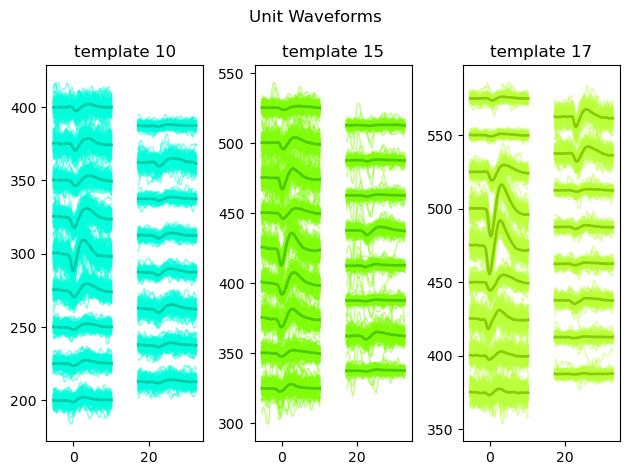

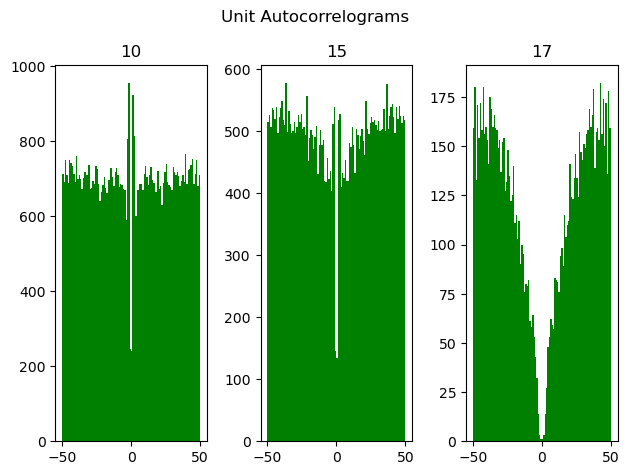

In [ ]:
import numpy as np

print(f"Unit ids: {sorter.unit_ids}") # check unit ids
plot_waveforms(analyzer, unit_ids = [10, 15, 17]) # plot waveforms of select units along probe positions
plot_autocorrelogram(sorter, unit_ids = [10, 15, 17]) # plot corresponding autocorrelograms